# Country Intelligence System using Machine Learning and Clustering

## Objective :

Analyze socio-economic indicators of countries and classify them into different development categories while identifying similar country groups using clustering techniques.

Data Collection

In [1]:
import pandas as pd
df = pd.read_csv("Country-data.csv")

Data Preprocessing

In [2]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['country_encoded'] = le.fit_transform(df['country'])

Exploratory Data Analysis

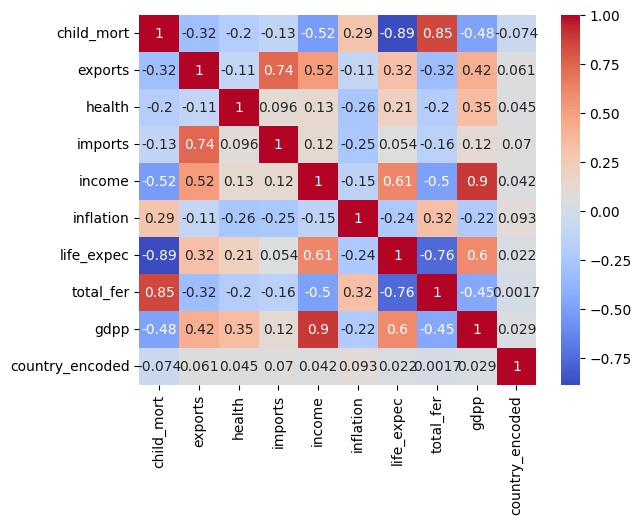

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

Create Target Variable

In [7]:
def category(row):
    if row['gdpp'] > 20000:
        return 2       # Developed
    elif row['gdpp'] > 5000:
        return 1       # Developing
    else:
        return 0       # Underdeveloped

df['status'] = df.apply(category, axis=1)

Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

X = df.drop(['country','status'], axis=1)
y = df['status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Classification Models

Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42)

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 0.9705882352941176


XGBoost

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train,y_train)

pred2 = xgb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred2))

Accuracy: 1.0


Customer Segmentation Equivalent (Country Segmentation)

K-Means

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

DBSCAN

In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

Cluster Visualization

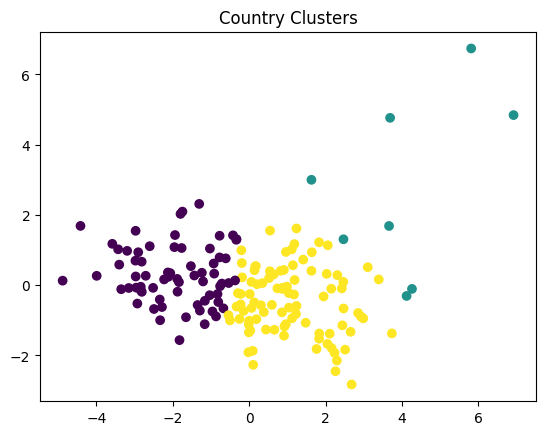

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['KMeans_Cluster'])

plt.title("Country Clusters")
plt.show()

Insights

* Countries with high GDP and life
expectancy form a developed cluster.

* Countries with high child mortality and low income form an underdeveloped cluster.

* Random Forest identifies the most important economic indicators.

* XGBoost provides higher predictive accuracy.